# **Sales Performance Analysis System**

**PROBLEM STATEMENT**

Modern organizations collect vast amounts of daily sales data; however, they often lack a clear, centralized understanding of their overall business performance, seasonal trends, and the specific contributions of different product categories. This project aims to address this gap by processing a structured sales dataset to extract meaningful business insights through data cleaning, statistical aggregation, and trend visualization.

**LOGIC EXPLANATION**

The project is executed through a structured six-step analytical workflow:

**1. Data Acquisition:** Load the product_sales_dataset_final.csv file into a Pandas DataFrame to begin the analysis.

**2. Data Inspection:** Review the dataset's structure, identify data types (objects, floats, ints), and check for missing values or null entries.

**3. Data Cleaning & Preprocessing:** Handle null values using df.fillna() and ensure temporal data is correctly formatted (e.g., converting Order_Date to a datetime object) for accurate analysis.

**4. Exploratory Data Analysis (EDA):** Use summary statistics and group-by operations to calculate key metrics like Total Revenue and Average Sales per category.Data

**5. Visualization:** Generate visual outputs using Matplotlib and Seaborn—specifically line plots for time-series trends, bar charts for category comparisons, and count plots for transaction distributions.

**6. Results Interpretation:** Summarize the key findings to draw actionable conclusions about which products or regions are driving business growth.

**SYSTEM**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the sales dataset
df = pd.read_csv('product_sales_dataset_final.csv')

# Initial inspection
print(df.info())
print(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Order_ID       10000 non-null  int64  
 1   Order_Date     10000 non-null  object 
 2   Customer_Name  10000 non-null  object 
 3   City           10000 non-null  object 
 4   State          10000 non-null  object 
 5   Region         10000 non-null  object 
 6   Country        10000 non-null  object 
 7   Category       10000 non-null  object 
 8   Sub_Category   10000 non-null  object 
 9   Product_Name   10000 non-null  object 
 10  Quantity       10000 non-null  int64  
 11  Unit_Price     10000 non-null  float64
 12  Revenue        10000 non-null  float64
 13  Profit         10000 non-null  float64
dtypes: float64(3), int64(2), object(9)
memory usage: 1.1+ MB
None
   Order_ID Order_Date     Customer_Name          City        State  Region  \
0         1   08-23-23      Bianca Brown  

In [ ]:
# Convert Order_Date from text to a Date object
df['Order_Date'] = pd.to_datetime(df['Order_Date'])

# Verify the change (Dtype should now be datetime64)
print(df['Order_Date'].dtypes)

# Check for any duplicates (good for data validation)
print(f"Total Duplicate Rows: {df.duplicated().sum()}")

datetime64[ns]
Total Duplicate Rows: 0


/tmp/ipykernel_24472/1757844727.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Order_Date'] = pd.to_datetime(df['Order_Date'])


In [ ]:
# --- 3. Exploratory Data Analysis (EDA) ---
# Summary statistics [cite: 65, 70]
print("\n--- Summary Statistics ---\n", df.describe())

# Category-wise aggregation
# Calculating total Revenue per Category
category_sales = df.groupby('Category')['Revenue'].sum().sort_values(ascending=False)
print("\n--- Total Revenue by Category ---\n", category_sales)


--- Summary Statistics ---
           Order_ID      Quantity    Unit_Price       Revenue        Profit
count  10000.00000  10000.000000  10000.000000  10000.000000  10000.000000
mean    5000.50000      1.849600    385.353689    715.869528    157.122257
std     2886.89568      1.088714    277.509694    738.705012    150.634933
min        1.00000      1.000000     19.730000     20.300000      4.360000
25%     2500.75000      1.000000    164.827500    230.222500     59.320000
50%     5000.50000      1.000000    308.140000    473.755000    110.405000
75%     7500.25000      2.000000    566.147500    890.640000    203.160000
max    10000.00000      8.000000   1372.890000   7110.960000   1760.890000

--- Total Revenue by Category ---
 Category
Electronics           2923782.77
Home & Furniture      2385671.95
Clothing & Apparel    1350706.07
Accessories            498534.49
Name: Revenue, dtype: float64


/tmp/ipykernel_24472/1156327847.py:7: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df.set_index('Order_Date').resample('M')['Revenue'].sum().plot(kind='line', marker='o', color='b')
/tmp/ipykernel_24472/1156327847.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_sales.index, y=category_sales.values, palette='viridis')
/tmp/ipykernel_24472/1156327847.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Region', palette='magma')


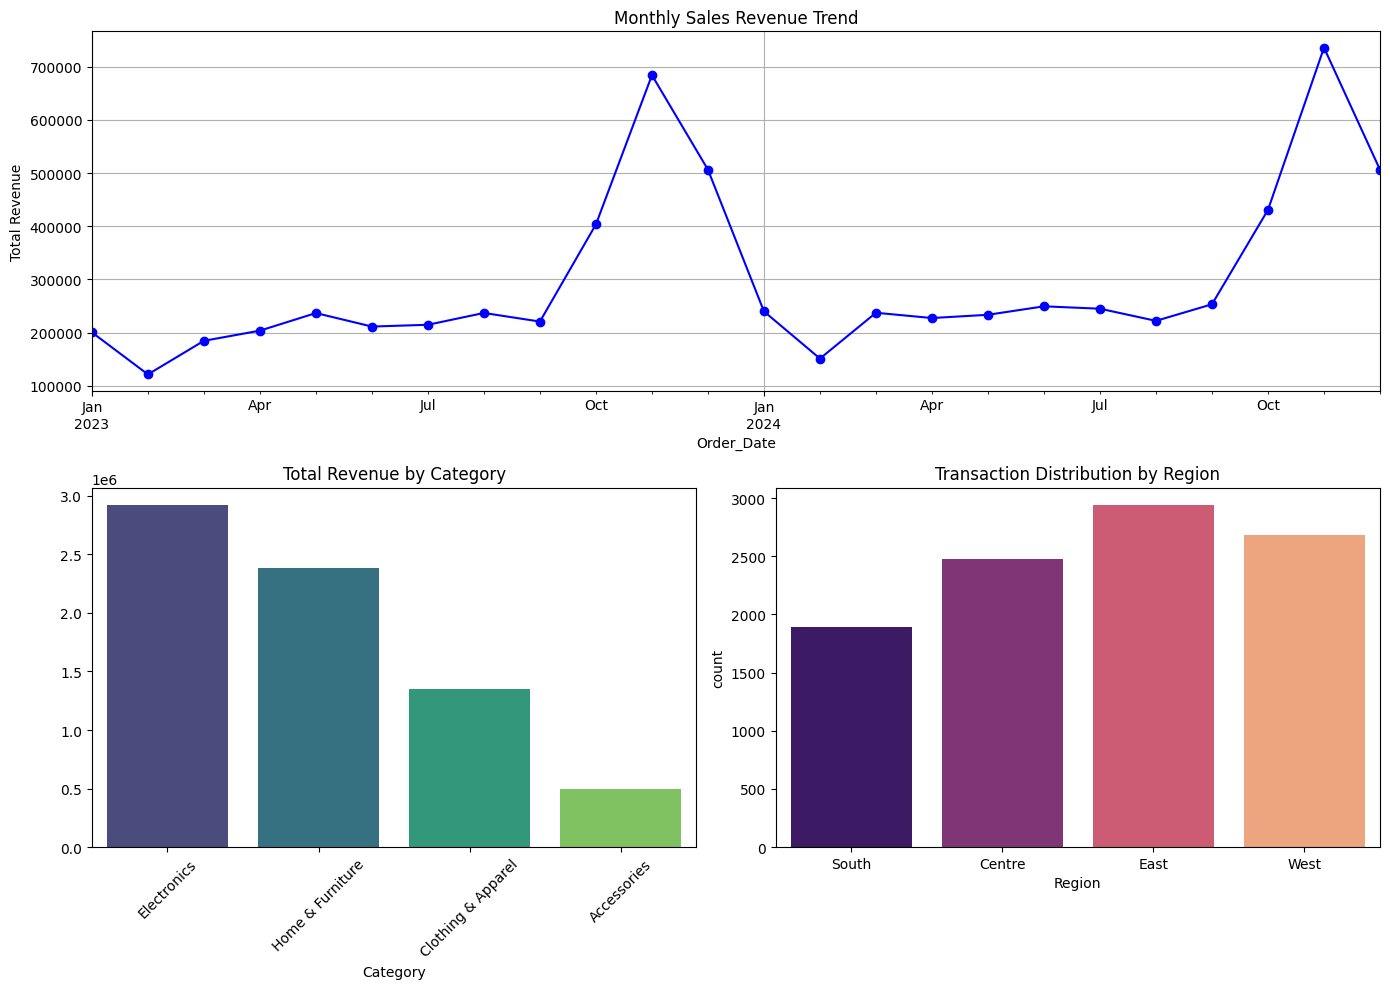

In [ ]:
# --- 4. Visualize Insights ---
plt.figure(figsize=(14, 10))

# A. Line Plot for Sales Trends
plt.subplot(2, 1, 1)
# Resampling by month to make the trend clearer
df.set_index('Order_Date').resample('M')['Revenue'].sum().plot(kind='line', marker='o', color='b')
plt.title('Monthly Sales Revenue Trend')
plt.ylabel('Total Revenue')
plt.grid(True)

# B. Bar Chart for Category-wise Sales
plt.subplot(2, 2, 3)
sns.barplot(x=category_sales.index, y=category_sales.values, palette='viridis')
plt.title('Total Revenue by Category')
plt.xticks(rotation=45)

# C. Count Plot for Transaction Distribution
plt.subplot(2, 2, 4)
sns.countplot(data=df, x='Region', palette='magma')
plt.title('Transaction Distribution by Region')

plt.tight_layout()
plt.show()